In [1]:
!pip install numpy
!pip install torch torchvision torchaudio
!pip install matplotlib
!pip install -U scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 8.0/8.0 MB 49.7 MB/s  0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---------------- ----------------------- 14.9/36.5 MB 72.3 MB/s eta 0:00:01
   ----------------------------- ---------- 26.7/36.5 MB 65.2 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.5 MB 64.4 MB/s eta 0:00:01
   ---------------------------------------- 36.5/36.5 MB 52.8 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- -----------

In [2]:
import platform
print(platform.architecture())

('64bit', 'WindowsPE')


In [3]:
import numpy as np
import torch as th
import matplotlib.pyplot as plt
import scipy.signal as sps

In [4]:
def load_iq(filename, dtype=np.int16, normalize=True):
    raw = np.fromfile(filename, dtype=dtype)

    I = raw[0::2]
    Q = raw[1::2]

    iq = I.astype(np.float32) + 1j * Q.astype(np.float32)

    if normalize and dtype == np.int16:
        iq /= 32768.0  # scale to [-1, 1]

    return iq

iq = load_iq("data/input_frameLen_128_setIndex_1_alphaIndex_1_frame1.iqdata")
print(iq[:10])

FileNotFoundError: [Errno 2] No such file or directory: 'data/input_frameLen_128_setIndex_1_alphaIndex_1_frame1.iqdata'

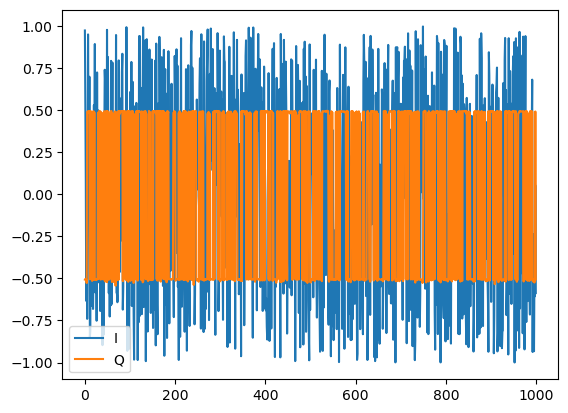

In [ ]:
plt.plot(iq.real[:1000])
plt.plot(iq.imag[:1000])
plt.legend(["I", "Q"])
plt.show()


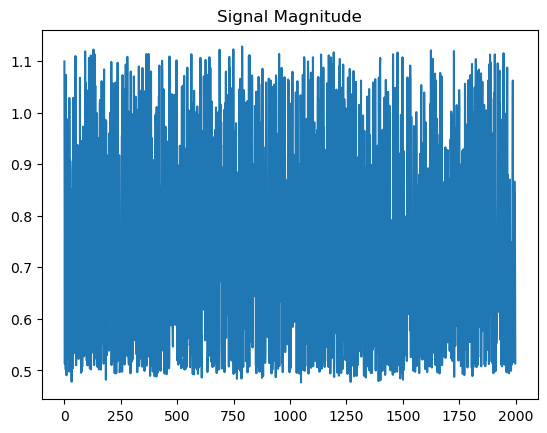

In [ ]:
plt.plot(np.abs(iq[:2000]))
plt.title("Signal Magnitude")
plt.show()

In [ ]:
# Taken from Demucs repo

def spectro(x, n_fft=512, hop_length=None, pad=0):
    *other, length = x.shape
    x = x.reshape(-1, length)
    is_mps = x.device.type == 'mps'
    if is_mps:
        x = x.cpu()
    z = th.stft(x,
                n_fft * (1 + pad),
                hop_length or n_fft // 4,
                window=th.hann_window(n_fft).to(x),
                win_length=n_fft,
                normalized=True,
                center=True,
                return_complex=True,
                pad_mode='reflect')
    _, freqs, frame = z.shape
    return z.view(*other, freqs, frame)

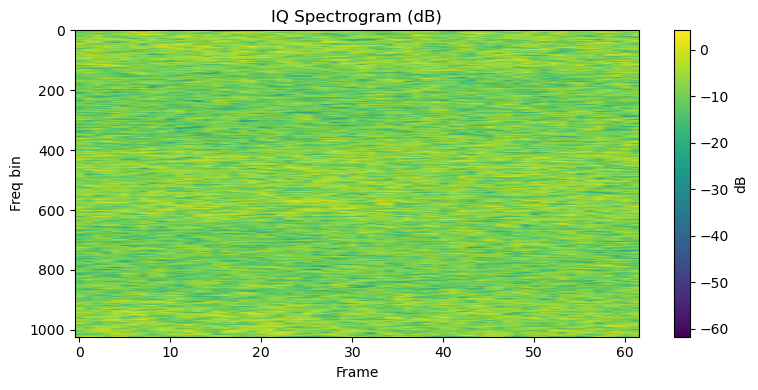

In [ ]:
# loader from earlier
def load_iq(filename, dtype=np.int16, normalize=True):
    raw = np.fromfile(filename, dtype=dtype)
    I = raw[0::2].astype(np.float32)
    Q = raw[1::2].astype(np.float32)
    iq = I + 1j * Q
    if normalize and dtype == np.int16:
        iq /= 32768.0
    return iq.astype(np.complex64)


# example usage
FILENAME = "data/input_frameLen_128_setIndex_1_alphaIndex_1_frame1.iqdata"
iq = load_iq(FILENAME)              # numpy complex64, shape (N,)
# make tensor and add batch dim (e.g. (1, N) ) or channel dim if needed by model
x = th.from_numpy(iq)               # complex64 tensor shape (N,)
x = x.unsqueeze(0)                  # shape (1, N) -> other=(1,)

# move to GPU if available
device = th.device("cuda") if th.cuda.is_available() else th.device("cpu")
x = x.to(device)

# compute spectrogram
n_fft = 1024
S_complex = spectro(x, n_fft=n_fft, hop_length=n_fft//4, pad=0)  # shape (1, freq_bins, time_frames)

# magnitude
eps = 1e-12
S_mag = th.abs(S_complex)
S_db = 20 * th.log10(S_mag + eps)

# convert to numpy for plotting
S_db_np = S_db[0].cpu().numpy()   # shape (freq_bins, time_frames)

plt.figure(figsize=(8,4))
plt.imshow(S_db_np[::-1, :], aspect='auto')  # origin upper -> flip for conventional view
plt.title("IQ Spectrogram (dB)")
plt.xlabel("Frame")
plt.ylabel("Freq bin")
plt.colorbar(label="dB")
plt.tight_layout()
plt.show()


In [ ]:
# Inverse STFT from Demucs

def ispectro(z, hop_length=None, length=None, pad=0):
    *other, freqs, frames = z.shape
    n_fft = 2 * freqs - 2
    z = z.view(-1, freqs, frames)
    win_length = n_fft // (1 + pad)
    is_mps = z.device.type == 'mps'
    if is_mps:
        z = z.cpu()
    x = th.istft(z,
                 n_fft,
                 hop_length,
                 window=th.hann_window(win_length).to(z.real),
                 win_length=win_length,
                 normalized=True,
                 length=length,
                 center=True)
    _, length = x.shape
    return x.view(*other, length)

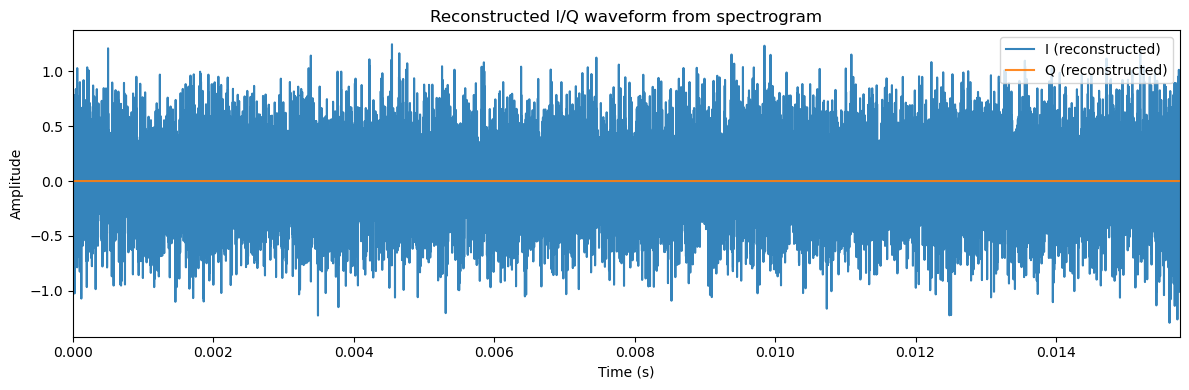

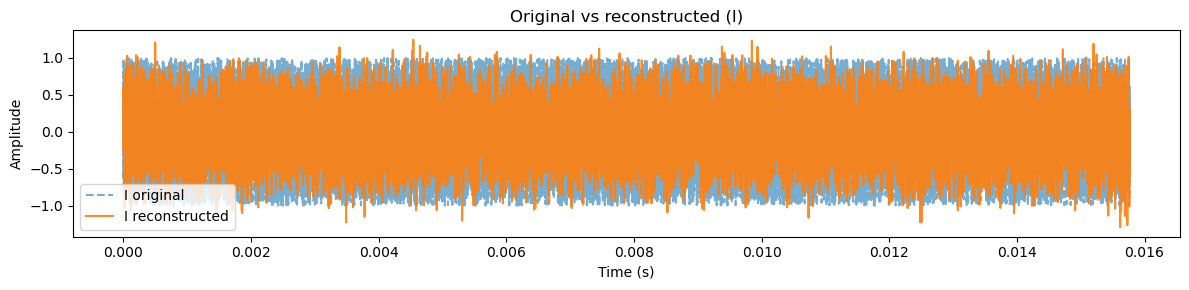

In [ ]:
# --- PARAMETERS ---
FILENAME = "data/input_frameLen_128_setIndex_1_alphaIndex_1_frame1.iqdata"
SAMPLE_RATE = 1_000_000  # set to actual sample rate or keep for seconds axis; use 1 for samples
n_fft = 1024
hop_length = n_fft // 4
pad = 0

# --- LOAD & PREPARE ---
orig = load_iq(FILENAME)                      # numpy complex array shape (N,)
orig_length = orig.shape[0]
x = th.from_numpy(orig).to(th.complex64).unsqueeze(0)  # shape (1, N)
device = th.device("cuda") if th.cuda.is_available() else th.device("cpu")
x = x.to(device)

# --- SPECTRO (uses your existing spectro function) ---
Z = spectro(x, n_fft=n_fft, hop_length=hop_length, pad=pad)  # shape (1, freqs, frames), complex

# --- INVERSE (uses your existing ispectro function) ---
x_rec = ispectro(Z, hop_length=hop_length, length=orig_length, pad=pad)  # shape (1, length)
x_rec = x_rec.squeeze(0).cpu().numpy()   # complex numpy array

# --- PLOTTING ---
t = np.arange(orig_length) / SAMPLE_RATE

plt.figure(figsize=(12,4))
plt.plot(t, x_rec.real, label='I (reconstructed)', alpha=0.9)
plt.plot(t, x_rec.imag, label='Q (reconstructed)', alpha=0.9)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend(loc='upper right')
plt.title('Reconstructed I/Q waveform from spectrogram')
plt.xlim(0, t.max())
plt.tight_layout()
plt.show()

# Optional: compare original vs reconstructed (I only)
plt.figure(figsize=(12,3))
plt.plot(t, orig.real, '--', label='I original', alpha=0.6)
plt.plot(t, x_rec.real, label='I reconstructed', alpha=0.9)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.title('Original vs reconstructed (I)')
plt.tight_layout()
plt.show()


Aligned reconstruction by lag = 3411 samples
Time-domain SINR: -0.68 dB (signal power 5.7955e-01, noise power 6.7798e-01)
Per-window SINR mean=-0.73 dB, std=0.21 dB


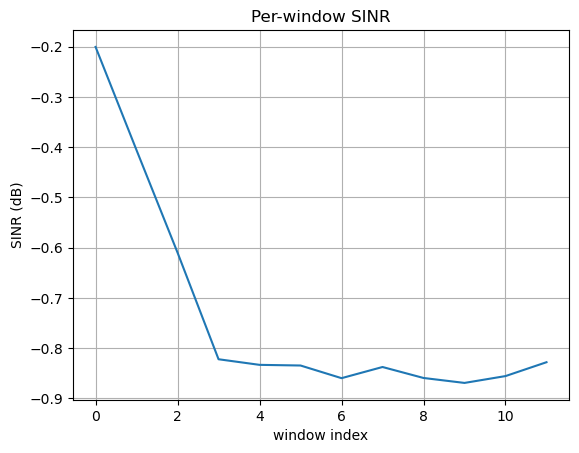

Freq-domain SINR (selected bins): -0.08 dB (selected bins=20)


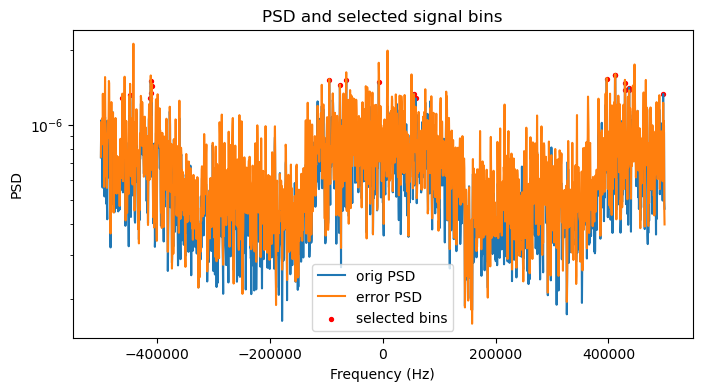

In [ ]:
# === A: Time-domain SINR / SNR (complex IQ) ===

# orig, x_rec must be complex numpy arrays of same length (from your notebook)
# if not aligned, use cross-correlation to align:
def align_by_xcorr(a, b):
    # returns b shifted to best align with a (no interpolation)
    # a,b are 1D complex arrays
    corr = sps.correlate(np.real(a), np.real(b), mode='full') + 1j * sps.correlate(np.imag(a), np.imag(b), mode='full')
    lag = corr.argmax() - (len(b)-1)
    if lag > 0:
        b2 = np.pad(b, (lag,0))[:len(a)]
    else:
        b2 = np.pad(b, (0,-lag))[:len(a)]
    return b2, lag

# optional alignment
x_rec_aligned, lag = align_by_xcorr(orig, x_rec)
if abs(lag) > 0:
    print(f"Aligned reconstruction by lag = {lag} samples")

# compute powers
signal_power = np.mean(np.abs(orig)**2)
noise_power  = np.mean(np.abs(orig - x_rec_aligned)**2)

sinr_db = 10 * np.log10(signal_power / (noise_power + 1e-16))
print(f"Time-domain SINR: {sinr_db:.2f} dB (signal power {signal_power:.4e}, noise power {noise_power:.4e})")

# Per-window SNR (optional) to see variation over time
win = 4096
hop = win // 4
frames = []
for start in range(0, len(orig)-win+1, hop):
    s_win = orig[start:start+win]
    r_win = x_rec_aligned[start:start+win]
    p_s = np.mean(np.abs(s_win)**2)
    p_n = np.mean(np.abs(s_win - r_win)**2) + 1e-16
    frames.append(10*np.log10(p_s / p_n))
frames = np.array(frames)
print(f"Per-window SINR mean={frames.mean():.2f} dB, std={frames.std():.2f} dB")
# quick plot (requires matplotlib)
import matplotlib.pyplot as plt
plt.plot(frames); plt.xlabel('window index'); plt.ylabel('SINR (dB)'); plt.title('Per-window SINR'); plt.grid(True)
plt.show()

# === B: Frequency-domain SINR estimate via Welch ===
# useful if signal occupies a limited band; we detect signal bins above threshold
fs = SAMPLE_RATE if 'SAMPLE_RATE' in globals() else 1.0
nperseg = 2048
f, Pxx_orig = sps.welch(orig, fs=fs, nperseg=nperseg, return_onesided=False)
_, Pxx_err  = sps.welch(orig - x_rec_aligned, fs=fs, nperseg=nperseg, return_onesided=False)

# convert to linear power spectral density
# detect "signal bins" as bins where original PSD significantly exceeds error PSD or above median
ratio = (Pxx_orig + 1e-16) / (Pxx_err + 1e-16)
# pick bins where ratio > threshold (e.g. 10 dB = 10)
mask = ratio > 10.0
if mask.sum() == 0:
    # fallback: choose top-k bins from Pxx_orig
    k = max(1, int(0.01 * len(Pxx_orig)))
    mask = np.zeros_like(mask); mask[np.argsort(Pxx_orig)[-k:]] = True

signal_band_power = np.mean(Pxx_orig[mask])
noise_band_power  = np.mean(Pxx_err[mask])
sinr_freq_db = 10*np.log10(signal_band_power / (noise_band_power + 1e-16))
print(f"Freq-domain SINR (selected bins): {sinr_freq_db:.2f} dB (selected bins={mask.sum()})")

# Optional: plot PSDs and mask
plt.figure(figsize=(8,4))
plt.semilogy(np.fft.fftshift(f), np.fft.fftshift(Pxx_orig), label='orig PSD')
plt.semilogy(np.fft.fftshift(f), np.fft.fftshift(Pxx_err), label='error PSD')
plt.scatter(np.fft.fftshift(f)[np.fft.fftshift(mask)], np.fft.fftshift(Pxx_orig)[np.fft.fftshift(mask)], color='red', s=8, label='selected bins')
plt.xlabel('Frequency (Hz)'); plt.ylabel('PSD'); plt.legend(); plt.title('PSD and selected signal bins')
plt.show()
